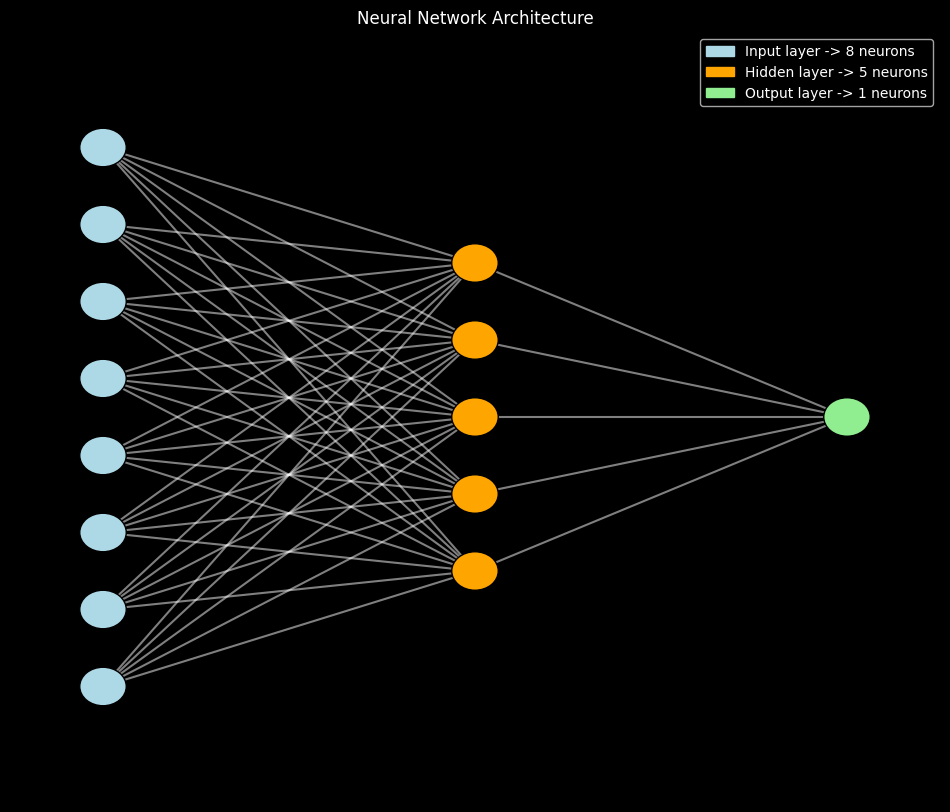

In [22]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('dark_background')

def draw_neural_net(ax, left, right, bottom, top, layer_sizes, colors):
    '''
    Draw a neural network with specified layer colors and a legend.
    '''
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom) / float(max(layer_sizes))
    h_spacing = (right - left) / float(n_layers - 1)

    # === Draw Nodes ===
    for n in range(n_layers):
        this_layer_size = layer_sizes[n]
        v_center = (top + bottom) / 2.0
        for i in range(this_layer_size):
            x = left + n * h_spacing
            y = v_center - (this_layer_size - 1) * v_spacing / 2.0 + i * v_spacing
            circle = plt.Circle(
                (x, y), v_spacing / 4.0, color=colors[n], ec='k', zorder=4
            )
            ax.add_patch(circle)
            # Add node number label
            ax.text(x, y, str(i + 1), ha='center', va='center')

    # === Draw Edges ===
    for n in range(n_layers - 1):
        this_layer_size = layer_sizes[n]
        next_layer_size = layer_sizes[n + 1]
        v_center_this = (top + bottom) / 2.0
        v_center_next = (top + bottom) / 2.0

        for i in range(this_layer_size):
            x_this = left + n * h_spacing
            y_this = v_center_this - (this_layer_size - 1) * v_spacing / 2.0 + i * v_spacing

            for j in range(next_layer_size):
                x_next = left + (n + 1) * h_spacing
                y_next = v_center_next - (next_layer_size - 1) * v_spacing / 2.0 + j * v_spacing
                line = plt.Line2D([x_this, x_next], [y_this, y_next], c='white', alpha=0.5)
                ax.add_artist(line)

    # === Legend ===
    handles = []
    labels = []
    layer = ["Input" , "Hidden", "Output"]
    for n in range(n_layers):
        handles.append(plt.Circle((0, 0), 0.1, color=colors[n]))
        labels.append(f'{layer[n]} layer -> {layer_sizes[n]} neurons')
    ax.legend(handles, labels, loc='upper right')


# === Draw the Neural Network ===
fig = plt.figure(figsize=(12, 10))
ax = fig.gca()
ax.axis('off')

layer_sizes = [8, 5, 1]
colors = ['lightblue', 'orange', 'lightgreen']

draw_neural_net(ax, 0.1, 0.9, 0.1, 0.9, layer_sizes, colors)
plt.title('Neural Network Architecture')
plt.show()


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load & Prepare Data
# -----------------------------
data_path = "/content/sample_data/california_housing_train.csv"
df = pd.read_csv(data_path)

# Separate features (X) and target (y)
X = df.drop(columns=["median_house_value"]).values
y = df["median_house_value"].values.reshape(-1, 1)

# Standardize inputs and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_std = scaler_X.fit_transform(X)
y_std = scaler_y.fit_transform(y)

# Convert to PyTorch tensors
X_torch = torch.tensor(X_std, dtype=torch.float32)
y_torch = torch.tensor(y_std, dtype=torch.float32)

# -----------------------------
# 2. Define the Neural Network
# -----------------------------
class PersonalNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, act_fun=nn.ReLU()):
        super(PersonalNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = act_fun
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

# Create model instance
input_dim = X_torch.shape[1]  # 8 features
hidden_dim = 5
output_dim = 1
model = PersonalNN(input_dim, hidden_dim, output_dim)

# -----------------------------
# 3. Training Setup
# -----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 5000
print_every = 1000

# -----------------------------
# 4. Training Loop
# -----------------------------
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    y_pred = model(X_torch)
    loss = criterion(y_pred, y_torch)
    loss.backward()
    optimizer.step()

    if epoch % print_every == 0:
        print(f"Epoch {epoch} | Training Loss: {loss.item():.6f}")

# -----------------------------
# 5. Prediction on Some Samples
# -----------------------------
print("\n--- Predictions ---")
model.eval()
with torch.no_grad():
    for i in range(5):
        x_sample = torch.tensor(X_std[i].reshape(1, -1), dtype=torch.float32)
        y_pred_std = model(x_sample).numpy()
        # Inverse transform to original scale
        y_pred_original = scaler_y.inverse_transform(y_pred_std)[0, 0]
        print(f"Row {i} | Predicted: {y_pred_original:.2f} | Actual: {y[i, 0]:.2f}")


Epoch 1000 | Training Loss: 0.261559
Epoch 2000 | Training Loss: 0.261498
Epoch 3000 | Training Loss: 0.261475
Epoch 4000 | Training Loss: 0.261519
Epoch 5000 | Training Loss: 0.261478

--- Predictions ---
Row 0 | Predicted: 44856.05 | Actual: 66900.00
Row 1 | Predicted: 87518.94 | Actual: 80100.00
Row 2 | Predicted: 50969.43 | Actual: 85700.00
Row 3 | Predicted: 112175.63 | Actual: 73400.00
Row 4 | Predicted: 61943.10 | Actual: 65500.00
